# EXP-12: Face Detection with Haar Cascades

## Aim
To write a Python program using OpenCV to perform the following image manipulations:
1. Extract ROI from an image
2. Perform face detection using Haar Cascades in static images
3. Perform eye detection in images
4. Perform face detection with label in real-time video from webcam

## Software Required
- Anaconda – Python 3.7 or above
- OpenCV (`opencv-python`)
- Matplotlib (`matplotlib`)
- Jupyter Notebook / any Python IDE


## Step 1: Import Necessary Libraries

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import urllib.request
import os

print("OpenCV version:", cv2.__version__)
print("All libraries imported successfully!")


OpenCV version: 4.13.0
All libraries imported successfully!


## Step 2: Load Haar Cascade Classifiers

We load pre-trained XML files for face and eye detection.
These files contain the cascade of weak classifiers trained using the Viola-Jones algorithm.


In [2]:
# Adjust paths if the XML files are in a different directory
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')
eye_cascade  = cv2.CascadeClassifier('haarcascade_eye.xml')

if face_cascade.empty():
    raise IOError("Could not load haarcascade_frontalface_default.xml — check the path.")
if eye_cascade.empty():
    raise IOError("Could not load haarcascade_eye.xml — check the path.")

print("Face cascade loaded:", not face_cascade.empty())
print("Eye  cascade loaded:", not eye_cascade.empty())


Face cascade loaded: True
Eye  cascade loaded: True


## Step 3: Verify Image Files

We use three images already present in the working directory:
- **1.jpg** – single person (frontal face)
- **2.jpg** – person with glasses
- **3.jpg** – group photo


In [3]:
import os

print("📁 Place your images in this folder:")
print("  ", os.getcwd())
print()

image_files = {"single": "1.png", "glasses": "2.png", "group": "3.png"}

all_found = True
for label, fname in image_files.items():
    path = os.path.join(os.getcwd(), fname)
    if os.path.exists(path):
        print(f"✔  Found : {fname}  ({label})")
    else:
        print(f"✘  MISSING: {fname}  → copy it to: {path}")
        all_found = False

if not all_found:
    raise FileNotFoundError("One or more image files are missing. "
                            "Copy them to the folder shown above, then re-run.")
else:
    print("\n✅ All images found. Proceed to the next cell.")


📁 Place your images in this folder:
   C:\Users\JK\Downloads

✔  Found : 1.png  (single)
✔  Found : 2.png  (glasses)
✔  Found : 3.png  (group)

✅ All images found. Proceed to the next cell.


## Step 4: Load and Display Images

Images are loaded in **grayscale** (flag `0`) because Haar cascades operate on
single-channel intensity data.


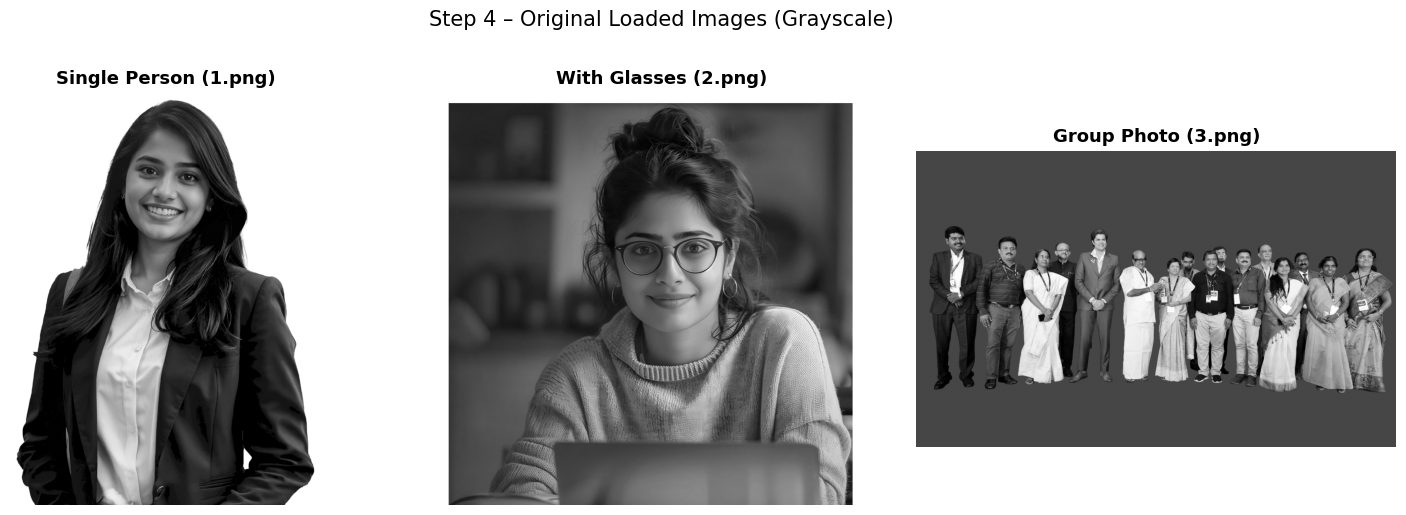

Image shapes → (3258, 2468) (745, 775) (1579, 2560)


In [6]:
img_single  = cv2.imread('1.png', 0)
img_glasses = cv2.imread('2.png', 0)
img_group   = cv2.imread('3.png', 0)

# Guard: catch missing files early with a clear message
for name, img in [('1.png', img_single), ('2.png', img_glasses), ('3.png', img_group)]:
    if img is None:
        raise FileNotFoundError(
            f"cv2.imread could not load '{name}'. "
            f"Make sure it is in: {os.getcwd()}"
        )

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = ['Single Person (1.png)', 'With Glasses (2.png)', 'Group Photo (3.png)']
images = [img_single, img_glasses, img_group]

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img, cmap='gray')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.axis('off')

plt.suptitle('Step 4 – Original Loaded Images (Grayscale)', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()
print("Image shapes →", img_single.shape, img_glasses.shape, img_group.shape)


## Step 5: Extract Region of Interest (ROI)

A Region of Interest (ROI) is a cropped sub-region of the image that focuses
attention on the area most likely to contain the object of interest.
Here we extract the upper-centre portion of the single-person image.


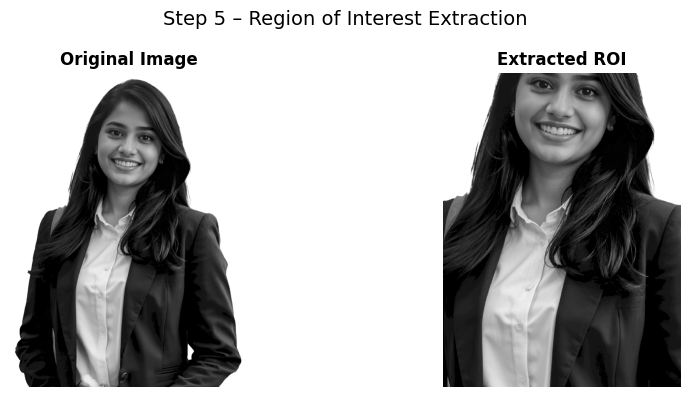

Original size: (3258, 2468)  →  ROI size: (2172, 1646)


In [7]:
h, w = img_single.shape
# Extract top-centre region (likely contains the face)
roi = img_single[h//6 : h - h//6, w//6 : w - w//6]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_single, cmap='gray')
axes[0].set_title('Original Image', fontweight='bold')
axes[0].axis('off')

axes[1].imshow(roi, cmap='gray')
axes[1].set_title('Extracted ROI', fontweight='bold')
axes[1].axis('off')

plt.suptitle('Step 5 – Region of Interest Extraction', fontsize=14)
plt.tight_layout()
plt.show()
print(f"Original size: {img_single.shape}  →  ROI size: {roi.shape}")


## Step 6: Define Face Detection Function

`detectMultiScale()` key parameters:
| Parameter | Meaning |
|-----------|---------|
| `scaleFactor` | How much the image is scaled down at each level (e.g. 1.1 = 10 % reduction) |
| `minNeighbors` | Minimum overlapping detections needed to retain a rectangle |
| `minSize` | Smallest face size to detect (in pixels) |

Larger `scaleFactor` → faster but less accurate.  
Larger `minNeighbors` → fewer false positives but may miss faces.


In [8]:
def detect_face(img, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30)):
    """
    Detect faces in a grayscale image and draw bounding boxes.

    Parameters
    ----------
    img          : np.ndarray – single-channel (grayscale) input image
    scaleFactor  : float     – pyramid scale (default 1.1)
    minNeighbors : int       – min detections to retain a candidate (default 5)
    minSize      : tuple     – minimum face size in pixels (default (30,30))

    Returns
    -------
    img_copy : np.ndarray – copy of input image with white rectangles drawn
    faces    : np.ndarray – array of detected bounding boxes (x, y, w, h)
    """
    img_copy = img.copy()
    faces = face_cascade.detectMultiScale(
        img_copy,
        scaleFactor  = scaleFactor,
        minNeighbors = minNeighbors,
        minSize      = minSize
    )
    for (x, y, w, h) in faces:
        cv2.rectangle(img_copy, (x, y), (x+w, y+h), 255, 10)  # white, thickness=10
    return img_copy, faces

print("detect_face() defined successfully.")


detect_face() defined successfully.


## Step 7: Define Eye Detection Function

Eye detection is typically applied **inside** an already-detected face ROI to
reduce false positives. For simplicity we apply it to the full image here.


In [9]:
def detect_eyes(img, scaleFactor=1.1, minNeighbors=10, minSize=(15, 15)):
    """
    Detect eyes in a grayscale image and draw bounding boxes.

    Parameters
    ----------
    img          : np.ndarray – single-channel (grayscale) input image
    scaleFactor  : float     – pyramid scale (default 1.1)
    minNeighbors : int       – higher value reduces false positives for eyes
    minSize      : tuple     – minimum eye size in pixels

    Returns
    -------
    img_copy : np.ndarray – copy with white rectangles around detected eyes
    eyes     : np.ndarray – array of detected bounding boxes (x, y, w, h)
    """
    img_copy = img.copy()
    eyes = eye_cascade.detectMultiScale(
        img_copy,
        scaleFactor  = scaleFactor,
        minNeighbors = minNeighbors,
        minSize      = minSize
    )
    for (x, y, w, h) in eyes:
        cv2.rectangle(img_copy, (x, y), (x+w, y+h), 255, 10)
    return img_copy, eyes

print("detect_eyes() defined successfully.")


detect_eyes() defined successfully.


## Step 8: Face Detection – Single Person Image

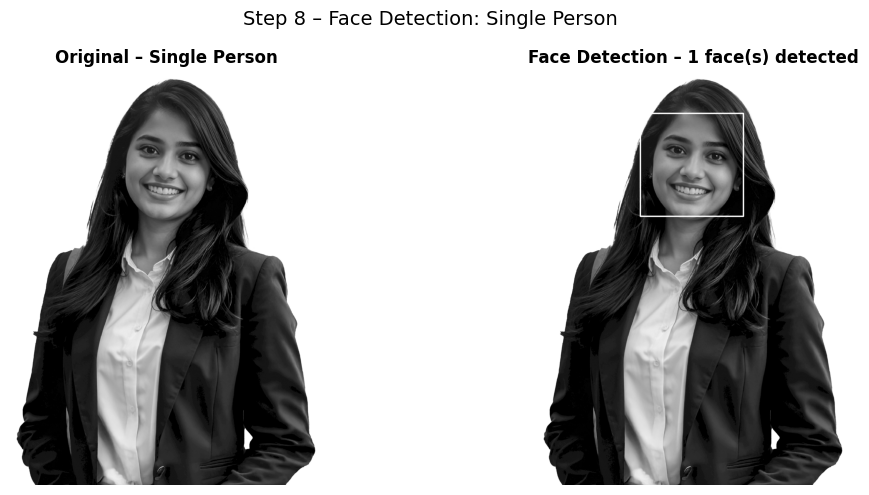

Detected 1 face(s). Bounding boxes: [array([812, 333, 810, 810], dtype=int32)]


In [10]:
result_single, faces_single = detect_face(img_single)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img_single, cmap='gray')
axes[0].set_title('Original – Single Person', fontweight='bold')
axes[0].axis('off')

axes[1].imshow(result_single, cmap='gray')
axes[1].set_title(f'Face Detection – {len(faces_single)} face(s) detected', fontweight='bold')
axes[1].axis('off')

plt.suptitle('Step 8 – Face Detection: Single Person', fontsize=14)
plt.tight_layout()
plt.show()
print(f"Detected {len(faces_single)} face(s). Bounding boxes: {list(faces_single) if len(faces_single) else 'None'}")


## Step 9: Face Detection – Person with Glasses

Glasses can occlude the eye region, which is one of the important features used
by the Haar classifier. We may need to reduce `minNeighbors` to detect the face.


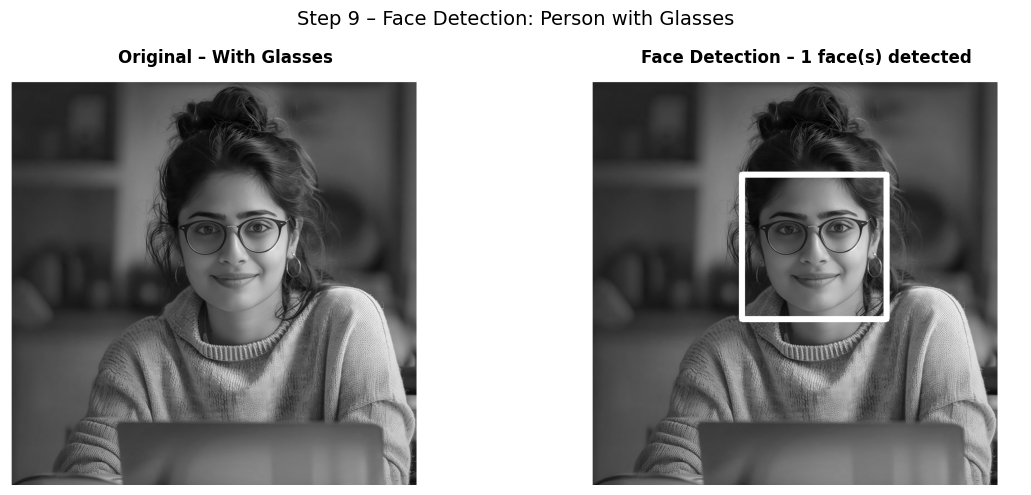

Detected 1 face(s).


In [11]:
result_glasses, faces_glasses = detect_face(img_glasses, minNeighbors=3)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img_glasses, cmap='gray')
axes[0].set_title('Original – With Glasses', fontweight='bold')
axes[0].axis('off')

axes[1].imshow(result_glasses, cmap='gray')
axes[1].set_title(f'Face Detection – {len(faces_glasses)} face(s) detected', fontweight='bold')
axes[1].axis('off')

plt.suptitle('Step 9 – Face Detection: Person with Glasses', fontsize=14)
plt.tight_layout()
plt.show()
print(f"Detected {len(faces_glasses)} face(s).")


## Step 10: Face Detection – Group Photo

Group photos require a lower `scaleFactor` (e.g. 1.05) to catch faces of
varying sizes, but this increases processing time.


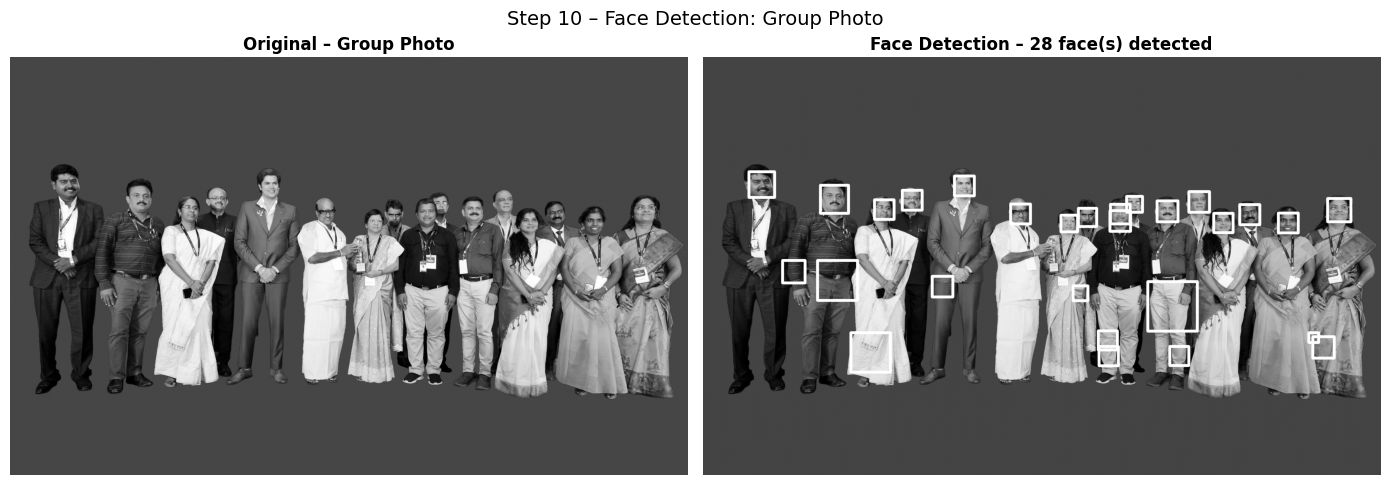

Detected 28 face(s). Bounding boxes: [array([949, 449,  75,  75], dtype=int32), array([173, 433,  97,  97], dtype=int32), array([443, 484, 106, 106], dtype=int32), array([1538,  556,   74,   74], dtype=int32), array([1161,  555,   75,   75], dtype=int32), array([1417,  571,   69,   69], dtype=int32), array([2287, 1041,   37,   37], dtype=int32), array([1928,  590,   73,   73], dtype=int32), array([2172,  589,   75,   75], dtype=int32), array([1351,  597,   63,   63], dtype=int32), array([1397,  864,   56,   56], dtype=int32), array([865, 828,  78,  78], dtype=int32), array([2026,  557,   76,   76], dtype=int32), array([1834,  508,   78,   78], dtype=int32), array([1599,  526,   60,   60], dtype=int32), array([2358,  534,   88,   88], dtype=int32), array([752, 503,  75,  75], dtype=int32), array([647, 539,  74,  74], dtype=int32), array([1714,  543,   79,   79], dtype=int32), array([1492, 1034,   72,   72], dtype=int32), array([1495, 1093,   73,   73], dtype=int32), array([1762, 1093,  

In [12]:
result_group, faces_group = detect_face(img_group, scaleFactor=1.05, minNeighbors=3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(img_group, cmap='gray')
axes[0].set_title('Original – Group Photo', fontweight='bold')
axes[0].axis('off')

axes[1].imshow(result_group, cmap='gray')
axes[1].set_title(f'Face Detection – {len(faces_group)} face(s) detected', fontweight='bold')
axes[1].axis('off')

plt.suptitle('Step 10 – Face Detection: Group Photo', fontsize=14)
plt.tight_layout()
plt.show()
print(f"Detected {len(faces_group)} face(s). Bounding boxes: {list(faces_group) if len(faces_group) else 'None'}")


## Step 11: Eye Detection

We apply eye detection to all three images.
Eye detection is more sensitive than face detection and prone to false positives
when applied to the entire image (e.g., detecting eyes in textured backgrounds).


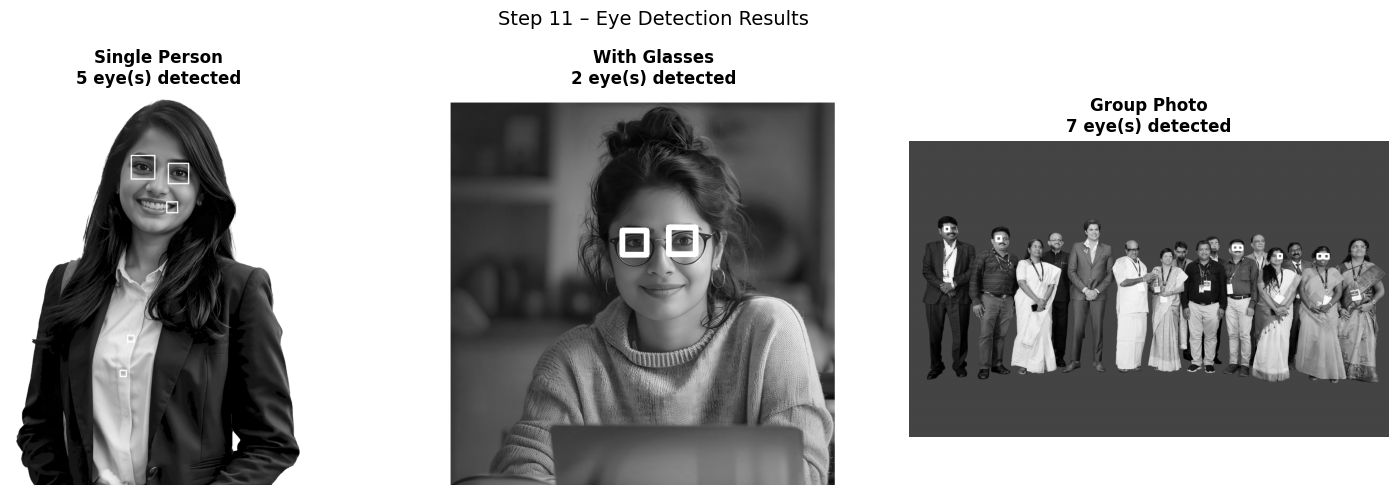

In [13]:
result_eye_single,  eyes_single  = detect_eyes(img_single)
result_eye_glasses, eyes_glasses = detect_eyes(img_glasses)
result_eye_group,   eyes_group   = detect_eyes(img_group)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
pairs = [
    (result_eye_single,  eyes_single,  'Single Person'),
    (result_eye_glasses, eyes_glasses, 'With Glasses'),
    (result_eye_group,   eyes_group,   'Group Photo'),
]
for ax, (img_r, eyes, title) in zip(axes, pairs):
    ax.imshow(img_r, cmap='gray')
    ax.set_title(f'{title}\n{len(eyes)} eye(s) detected', fontweight='bold')
    ax.axis('off')

plt.suptitle('Step 11 – Eye Detection Results', fontsize=14)
plt.tight_layout()
plt.show()


## Step 12: Combined Face + Eye Detection

Best practice: detect eyes **within** the face bounding box to reduce false positives.


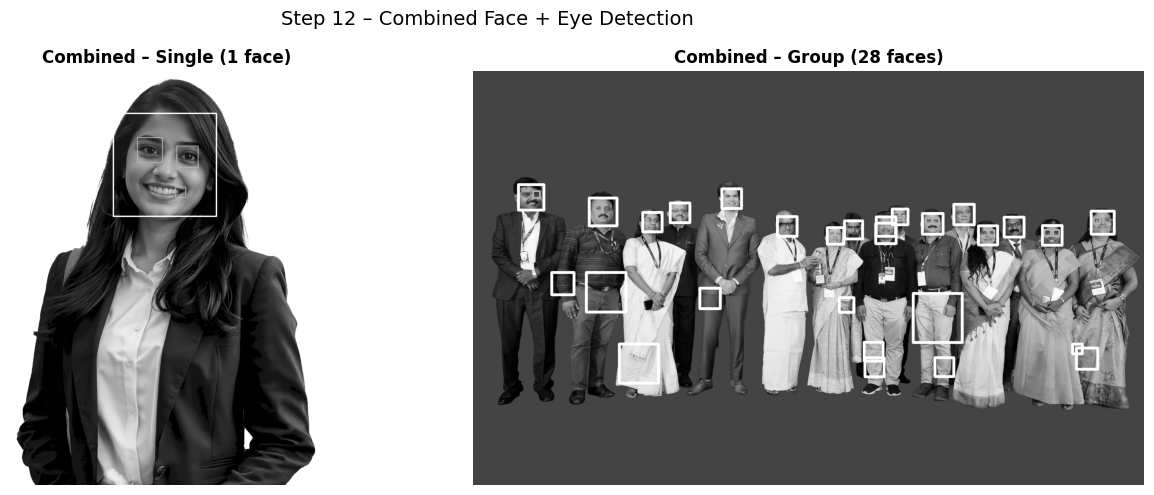

In [14]:
def detect_face_and_eyes(img, face_scale=1.1, face_neighbors=5,
                          eye_scale=1.1,  eye_neighbors=10):
    """Detect faces first, then detect eyes within each face ROI."""
    img_copy = img.copy()
    faces = face_cascade.detectMultiScale(
        img_copy, scaleFactor=face_scale, minNeighbors=face_neighbors, minSize=(30, 30)
    )
    for (fx, fy, fw, fh) in faces:
        cv2.rectangle(img_copy, (fx, fy), (fx+fw, fy+fh), 255, 10)   # face box

        face_roi = img_copy[fy:fy+fh, fx:fx+fw]                        # crop face ROI
        eyes = eye_cascade.detectMultiScale(
            face_roi, scaleFactor=eye_scale, minNeighbors=eye_neighbors, minSize=(10, 10)
        )
        for (ex, ey, ew, eh) in eyes:
            # Coordinates are relative to face ROI – shift back to full-image coords
            cv2.rectangle(img_copy,
                          (fx+ex, fy+ey),
                          (fx+ex+ew, fy+ey+eh),
                          180, 5)                                        # gray, thinner box

    return img_copy, faces

combined_single, f_s = detect_face_and_eyes(img_single)
combined_group,  f_g = detect_face_and_eyes(img_group, face_scale=1.05, face_neighbors=3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(combined_single, cmap='gray')
axes[0].set_title(f'Combined – Single ({len(f_s)} face)', fontweight='bold')
axes[0].axis('off')

axes[1].imshow(combined_group, cmap='gray')
axes[1].set_title(f'Combined – Group ({len(f_g)} faces)', fontweight='bold')
axes[1].axis('off')

plt.suptitle('Step 12 – Combined Face + Eye Detection', fontsize=14)
plt.tight_layout()
plt.show()


## Step 13: Real-Time Face Detection via Webcam

> **Note:** Run this cell in a local Jupyter environment connected to a webcam.
> This cell will **not** work inside Google Colab or a remote server.

Press **ESC** to stop the webcam stream.


In [15]:
# ──────────────────────────────────────────────────────────────────────────────
# Real-time webcam face detection with label overlay
# Press ESC (key code 27) to exit
# ──────────────────────────────────────────────────────────────────────────────

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Webcam not available in this environment. Skipping real-time demo.")
else:
    print("Webcam opened. Press ESC inside the video window to quit.")
    while True:
        ret, frame = cap.read()
        if not ret:
            print("Failed to grab frame.")
            break

        gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        faces = face_cascade.detectMultiScale(
            gray_frame,
            scaleFactor  = 1.1,
            minNeighbors = 5,
            minSize      = (30, 30)
        )

        for (x, y, w, h) in faces:
            cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 255, 255), 3)
            label = f"Face ({w}x{h})"
            cv2.putText(frame, label,
                        (x, y - 10),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.7, (255, 255, 255), 2)

        cv2.imshow("Real-Time Face Detection  [ESC to quit]", frame)

        key = cv2.waitKey(1) & 0xFF
        if key == 27:   # ESC
            print("ESC pressed – stopping.")
            break

    cap.release()
    cv2.destroyAllWindows()
    print("Webcam released. All windows closed.")


Webcam opened. Press ESC inside the video window to quit.


KeyboardInterrupt: 

## Step 14: Summary Comparison – All Detection Results

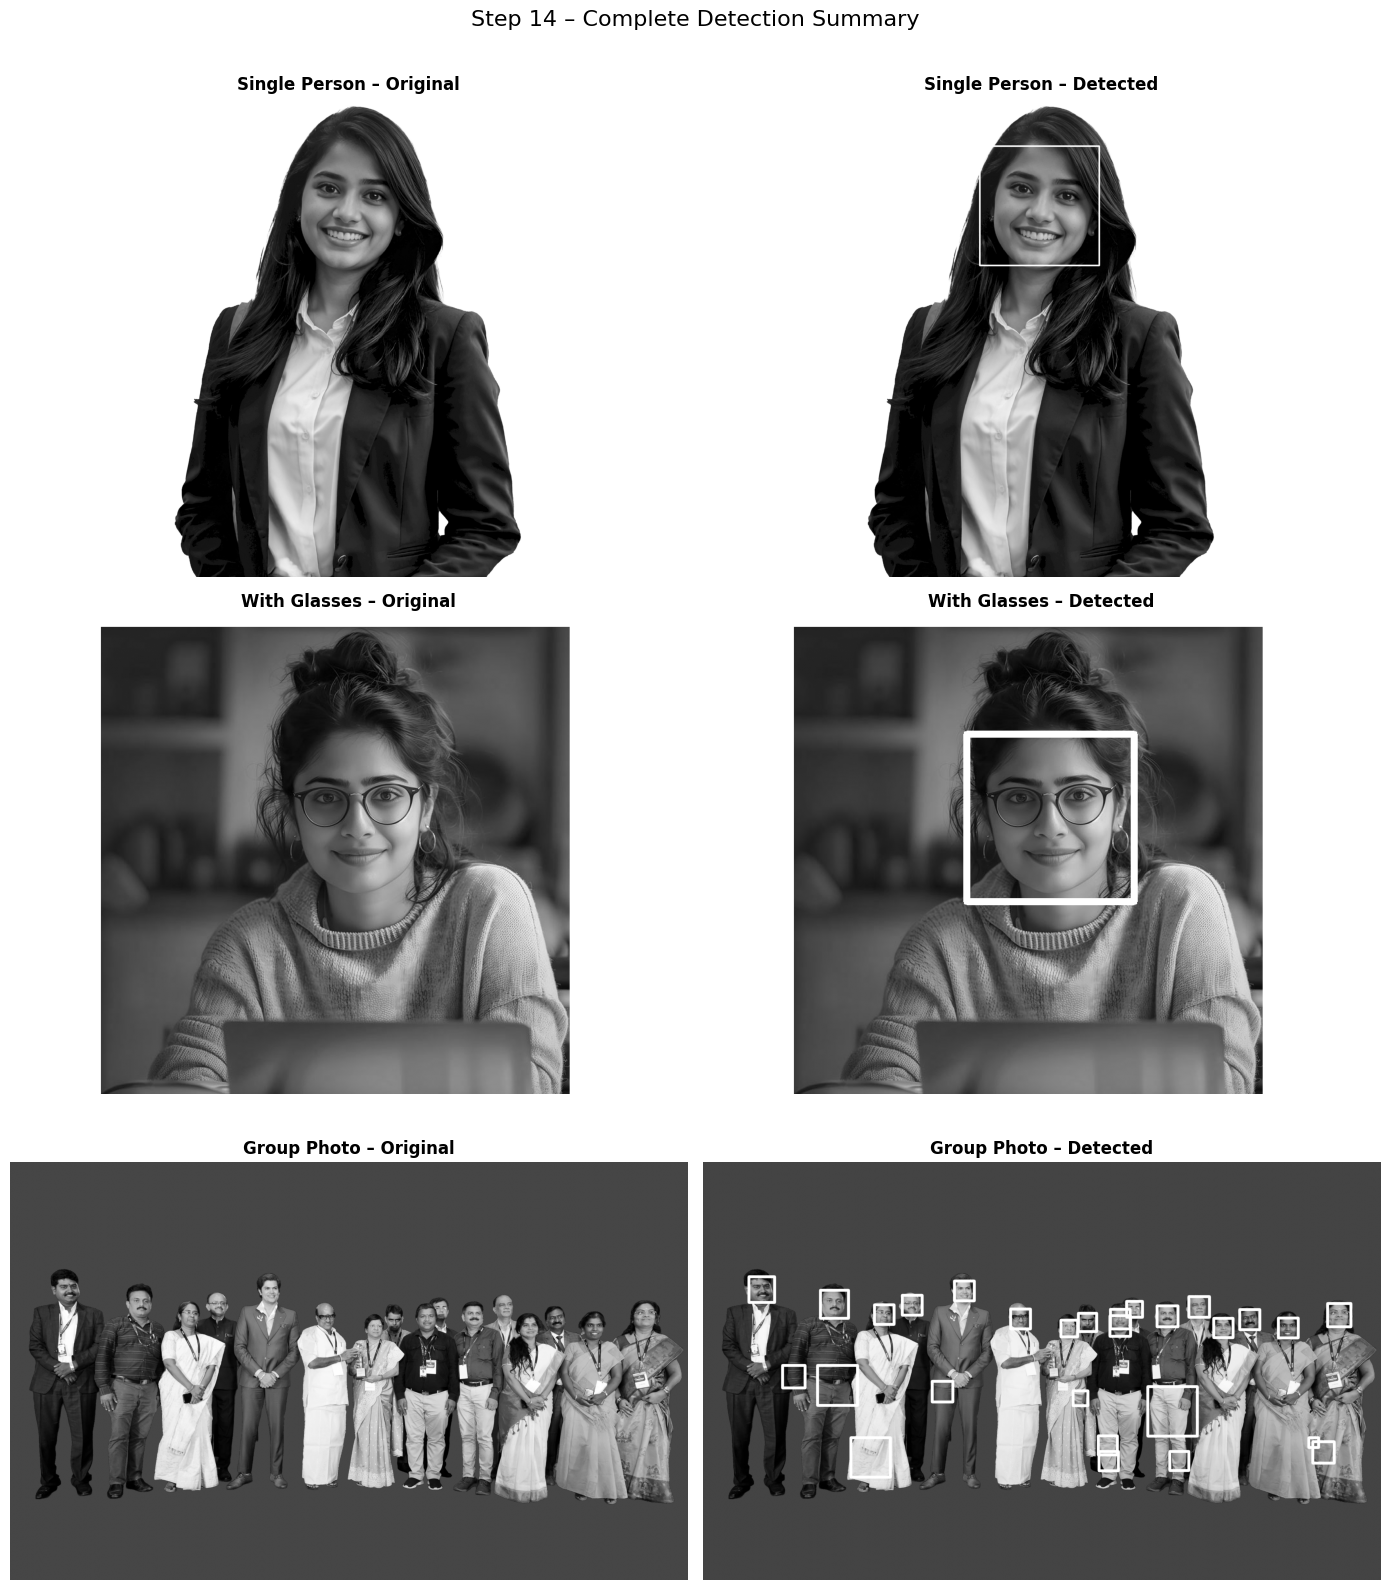

In [16]:
fig, axes = plt.subplots(3, 2, figsize=(14, 16))

rows = [
    (img_single,  result_single,  'Single Person'),
    (img_glasses, result_glasses, 'With Glasses'),
    (img_group,   result_group,   'Group Photo'),
]

for row_ax, (orig, detected, title) in zip(axes, rows):
    row_ax[0].imshow(orig,     cmap='gray');  row_ax[0].set_title(f'{title} – Original',  fontweight='bold'); row_ax[0].axis('off')
    row_ax[1].imshow(detected, cmap='gray');  row_ax[1].set_title(f'{title} – Detected',  fontweight='bold'); row_ax[1].axis('off')

plt.suptitle('Step 14 – Complete Detection Summary', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


## Step 15: Observations, Limitations & Conclusion

### Observations

| Test Case | Result | Notes |
|-----------|--------|-------|
| Single frontal face | ✅ Detected | High accuracy for upright, well-lit face |
| Face with glasses | ⚠️ Reduced accuracy | Glasses occlude eye region – key feature for classifier |
| Group photo | ⚠️ Variable | Small or partially occluded faces may be missed |
| Eye detection | ⚠️ Sensitive | Higher false-positive rate if not constrained to face ROI |

### Limitations of Haar-based Detection

1. **Pose sensitivity** – Haar cascades are trained on frontal faces; profile or tilted faces are often missed.
2. **Lighting** – Strong shadows or uneven lighting degrade performance significantly.
3. **Occlusion** – Glasses, masks, hands, or hair can cover key facial features.
4. **Scale range** – The pyramid scale and `minSize` parameters must be tuned per use case.
5. **False positives** – The classifier may fire on textured regions (e.g., fabric, foliage).
6. **Speed vs. accuracy trade-off** – Lower `scaleFactor` improves accuracy but is slower.

### Conclusion

We successfully implemented a full face-detection pipeline using OpenCV's Haar Cascade
classifiers. The pipeline:
- Loaded and displayed grayscale images
- Applied `detectMultiScale()` with tuned parameters for single-person, glasses, and group scenarios
- Visualized bounding boxes using Matplotlib
- Demonstrated eye detection both standalone and within face ROIs
- Provided a real-time webcam detection cell (requires a local environment with a webcam)

Haar Cascades remain a fast, lightweight baseline for face detection. For production use,
deep-learning–based detectors (e.g. DNN module in OpenCV, MTCNN, RetinaFace) offer
significantly better accuracy under real-world conditions.
